# Ultrasoft and PAW pseudopotentials

Norm conservation is what makes a pseudopotential expensive: the pseudo-orbital has to carry
the same charge as the all-electron one inside the core, which fixes how smooth it can be.
Ultrasoft drops that constraint and puts the missing charge back as an **augmentation
charge** $Q_{ij}(\mathbf r)$; PAW keeps a full radial description of each sphere on top of
that. The payoff is the cutoff: the same accuracy on oxygen or a transition metal at a third
of the plane waves a norm-conserving dataset needs.

The density gains a second piece that lives only inside the spheres, and the eigenproblem
gains an overlap operator:

$$n(\mathbf r) = \sum_{n\mathbf k} f_{n\mathbf k}\,|\psi_{n\mathbf k}(\mathbf r)|^2
  \;+\; \sum_{I,ij} \rho^I_{ij}\,Q^I_{ij}(\mathbf r),
\qquad
\hat S = 1 + \sum_{I,ij} q^I_{ij}\,|\beta^I_i\rangle\langle\beta^I_j|,
\qquad q^I_{ij} = \int Q^I_{ij}\,d\mathbf r$$

Without norm conservation $\langle\psi|\psi\rangle$ is no longer the charge, so
$H\psi = \varepsilon S\psi$ is a *generalised* eigenproblem. Get either half wrong and the
integrated density stops being the number of electrons, which is a sharper test than any
energy because it is exact rather than approximate.

| against `pw.x` | pypresso | difference |
|---|---|---|
| norm-conserving silicon, `ecutrho = 8 ecutwfc` | **-15.79449489 Ry** | 9.2e-10 |
| **ultrasoft** silicon | **-22.75348130 Ry** | 2.4e-09 |
| **PAW** silicon | **-89.27493665 Ry** | 2.9e-09 |
| **PAW**, eight atoms | **-357.09973538 Ry** | 2.3e-09 |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from pypresso import Calculator
from pypresso.io import comparison_table, read_qe_output

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

paw = Calculator.from_file(CASES / "si2-paw.in", pseudo_dir=PSEUDO, announce=False)
print("silicon, PAW:   E = %.8f Ry" % paw.get_scf().total_energy)

silicon, PAW:   E = -89.27493665 Ry


## Two grids, and a charge that is short-ranged

The wavefunctions stay smooth, so they keep the cutoff they always had; the augmentation
charge is sharp and needs a denser one. That is the whole meaning of `ecutrho` -- a
**smooth** grid carrying the wavefunctions and a **dense** grid carrying the density, with
the ratio between them set by how localised $Q_{ij}$ is. The two grids and their
$\mathbf G$-vector counts are chosen the way `pw.x` chooses them:

In [2]:
basis = paw.calculation.basis
qe = read_qe_output(CASES / "reference.out.si2-paw")

print("dual = ecutrho / ecutwfc = %g" % (paw.system.ecutrho / paw.system.ecutwfc))
print("dense    %6d G-vectors, FFT %-12s (pw.x: %6d, %s)"
      % (basis.dense.ngm, basis.dense.grid, qe.ngm_dense, qe.fft_dense))
print("smooth   %6d G-vectors, FFT %-12s (pw.x: %6d, %s)"
      % (basis.smooth.ngm, basis.smooth.grid, qe.ngm_smooth, qe.fft_smooth))

dual = ecutrho / ecutwfc = 8
dense      9185 G-vectors, FFT (32, 32, 32) (pw.x:   9185, (32, 32, 32))
smooth     3143 G-vectors, FFT (24, 24, 24) (pw.x:   3143, (24, 24, 24))


And this is what the datasets look like inside the sphere. On the left, PAW's pair of
partial waves: the all-electron orbital with its core oscillations and the smooth
pseudo-orbital that replaces it, identical outside the augmentation radius and different
inside it, which is the whole construction. On the right, the augmentation charge that makes
up the difference in the density, for the PAW dataset and for the ultrasoft one beside it --
and it dies at the same radius, which is why a denser grid is needed only there.

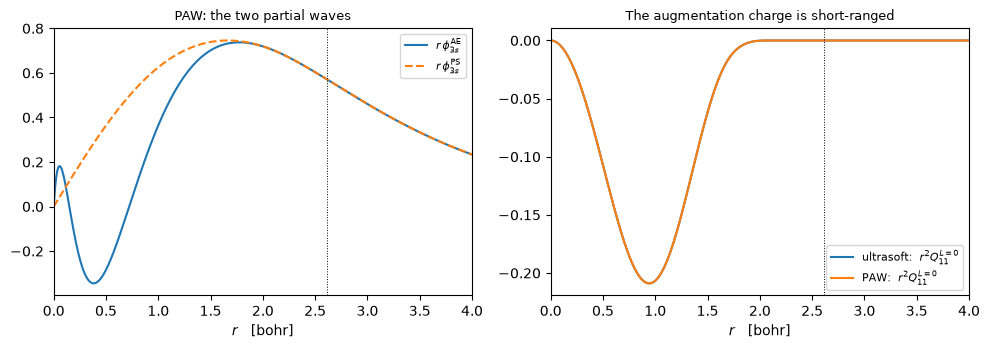

In [3]:
from pypresso.pseudo import read_upf     # no facade route to a dataset's radial tables

data = read_upf(PSEUDO / "Si.pz-n-kjpaw_psl.0.1.UPF")
soft = read_upf(PSEUDO / "Si.pz-n-rrkjus_psl.0.1.UPF")
edge = data.r[data.paw.cutoff_index - 1]

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.6))
axes[0].plot(data.r, data.paw.ae_wfc[0], label=r"$r\,\phi^{\rm AE}_{3s}$")
axes[0].plot(data.r, data.paw.ps_wfc[0], "--", label=r"$r\,\phi^{\rm PS}_{3s}$")
axes[0].set_title("PAW: the two partial waves", fontsize=9)
for label, dataset in (("ultrasoft", soft), ("PAW", data)):
    axes[1].plot(dataset.r, dataset.augmentation.qfuncl[0, 0, 0],
                 label=r"%s:  $r^2 Q^{L=0}_{11}$" % label)
axes[1].set_title("The augmentation charge is short-ranged", fontsize=9)
for ax in axes:
    ax.axvline(edge, color="k", lw=0.7, ls=":")
    ax.set_xlim(0.0, 4.0)
    ax.set_xlabel("$r$   [bohr]")
    ax.legend(fontsize=8)
fig.tight_layout()

The dotted line is the augmentation radius. Outside it the two partial waves lie on top of
each other and $Q_{ij}$ is zero; inside it the pseudo-orbital is smooth where the
all-electron one is not, and $Q_{ij}$ is exactly the charge that difference costs.

**The two $Q$ curves are one curve.** They are not merely similar: on these two datasets,
generated from the same all-electron reference, $r^2 Q^{L=0}_{11}$ is bit for bit the same
array. That is the relationship between the two schemes in one picture -- PAW is not a
different way of putting the charge back, it is ultrasoft *plus* a retained one-centre
description of the sphere, which is what buys back the all-electron quantities the pseudo
density has thrown away.

## Against Quantum ESPRESSO

Four cells: norm-conserving at the same dual so that the two-grid machinery is exercised
without an augmentation charge, then ultrasoft, then PAW, then PAW on eight atoms.

In [4]:
rows = []
for case in ("si2-nc-dual8", "si2-us", "si2-paw", "si8-paw"):
    ours = Calculator.from_file(CASES / f"{case}.in", pseudo_dir=PSEUDO,
                                announce=False).get_scf()
    rows.append((case, ours.total_energy,
                 read_qe_output(CASES / f"reference.out.{case}").total_energy))

print(comparison_table(rows, fmt="{:.8f}",
                       headers=("case", "pypresso [Ry]", "pw.x", "difference")))

case          pypresso [Ry]           pw.x  difference
si2-nc-dual8   -15.79449489   -15.79449489     9.2e-10
si2-us         -22.75348130   -22.75348130     2.4e-09
si2-paw        -89.27493665   -89.27493665     2.9e-09
si8-paw       -357.09973538  -357.09973538     2.3e-09


The screened coefficients $D_{ij}$ are the other thing that changes. With an augmentation
charge they stop being constants read from the file and pick up
$\int V_{\rm eff}(\mathbf r)\,Q_{ij}(\mathbf r)\,d\mathbf r$, so they follow the potential
through the self-consistent loop instead of sitting still. PAW adds its one-centre terms on
top of that -- a radial Poisson solve and a spherical quadrature inside each sphere -- which
is what lets it reconstruct all-electron quantities the pseudo density has thrown away.

The one-centre term is about 75% of PAW's total energy, and most of *that* is a constant:
the exchange-correlation energy of the frozen core, which the dataset fixes and no
calculation changes.

---
The tests behind this notebook: `tests/regression/test_uspp.py`, which holds the total
energies and their term-by-term breakdown, the eigenvalues, the augmented density
integrating to the electron count on every case, and the augmentation charge reproduced
against each dataset's own tabulated $q_{ij}$.